# Customer Churn Prediction — Telco dataset

**Business question:** which customers are likely to leave, and what drives churn, so that the retention team can target the right customers?

Plan: 1) data cleaning · 2) exploratory data analysis · 3) feature engineering · 4) model comparison with stratified 5-fold cross-validation · 5) evaluation on a held-out test set · 6) churn drivers & business recommendations.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from xgboost import XGBClassifier

SEED = 42
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Data loading & cleaning

In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
print(df.shape)
# TotalCharges is stored as text; blank values correspond to brand-new customers (tenure = 0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
print("Missing TotalCharges:", df["TotalCharges"].isna().sum(), "— tenure of those rows:", df.loc[df.TotalCharges.isna(), "tenure"].unique())
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["Churn"] = (df["Churn"] == "Yes").astype(int)
df = df.drop(columns="customerID")
print("Churn rate: {:.1%}".format(df.Churn.mean()))
df.head()

(7043, 21)
Missing TotalCharges: 11 — tenure of those rows: [0]
Churn rate: 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Exploratory data analysis

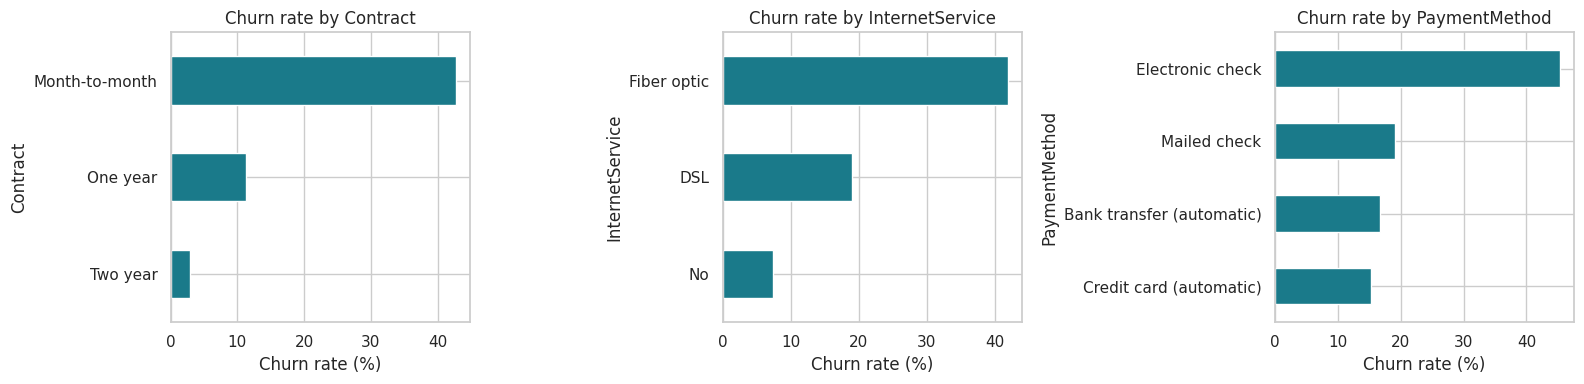

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    (df.groupby(col)["Churn"].mean().sort_values() * 100).plot.barh(ax=ax, color="#1A7A8A")
    ax.set_xlabel("Churn rate (%)"); ax.set_title(f"Churn rate by {col}")
plt.tight_layout(); plt.savefig(FIG / "churn_by_segment.png", dpi=120); plt.show()

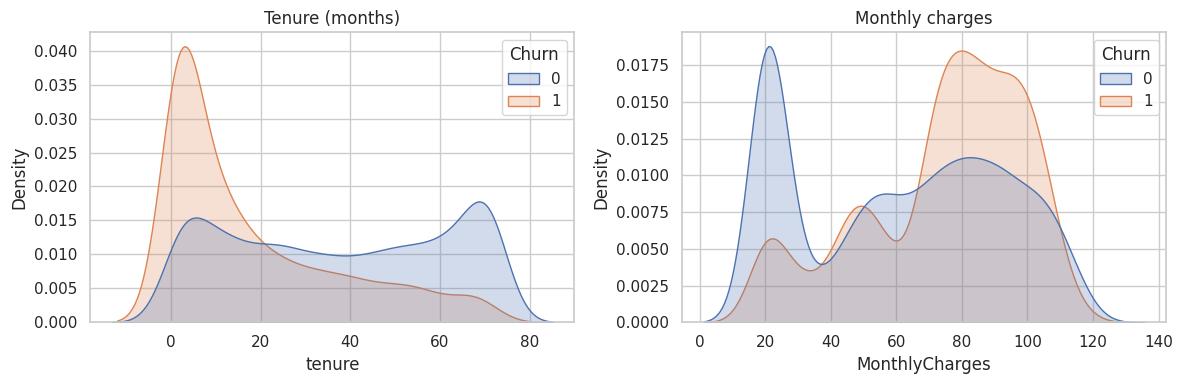

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False, fill=True, ax=axes[0]); axes[0].set_title("Tenure (months)")
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", common_norm=False, fill=True, ax=axes[1]); axes[1].set_title("Monthly charges")
plt.tight_layout(); plt.savefig(FIG / "tenure_charges.png", dpi=120); plt.show()

**EDA takeaways**
- Month-to-month contracts, fiber optic internet and electronic-check payment show the highest churn rates.
- Churners are concentrated in the first months of tenure and pay higher monthly charges.
- The target is imbalanced (~27% churn) → we evaluate with **F1 and ROC-AUC**, not accuracy.

## 3. Feature engineering

In [5]:
services = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
def add_features(d):
    d = d.copy()
    d["n_services"] = (d[services] == "Yes").sum(axis=1)
    d["tenure_group"] = pd.cut(d["tenure"], [-1, 6, 12, 24, 48, 72], labels=["0-6","7-12","13-24","25-48","49-72"]).astype(str)
    d["avg_monthly_spend"] = np.where(d["tenure"] > 0, d["TotalCharges"] / d["tenure"].clip(lower=1), d["MonthlyCharges"])
    d["is_new_customer"] = (d["tenure"] <= 6).astype(int)
    d["no_protection"] = ((d["OnlineSecurity"] != "Yes") & (d["TechSupport"] != "Yes")).astype(int)
    return d
dfe = add_features(df)
X, y = dfe.drop(columns="Churn"), dfe["Churn"]
num_cols = X.select_dtypes("number").columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
print(len(num_cols), "numeric /", len(cat_cols), "categorical features")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
pre = ColumnTransformer([("num", StandardScaler(), num_cols), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

8 numeric / 16 categorical features


## 4. Model comparison — stratified 5-fold cross-validation

In [6]:
pos_w = (y_train == 0).sum() / (y_train == 1).sum()
models = {
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", C=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_w, random_state=SEED, eval_metric="logloss"),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, m in models.items():
    s = cross_validate(Pipeline([("pre", pre), ("model", m)]), X_train, y_train, cv=cv, scoring=["roc_auc","f1","recall","precision"])
    rows.append({"model": name, **{k.replace("test_",""): f"{s[k].mean():.3f} ± {s[k].std():.3f}" for k in s if k.startswith("test_")}})
cv_results = pd.DataFrame(rows).set_index("model"); cv_results

,roc_auc,f1,recall,precision
model,,,,
Baseline (majority class),0.500 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000
Logistic Regression,0.847 ± 0.011,0.627 ± 0.021,0.791 ± 0.034,0.520 ± 0.016
Random Forest,0.845 ± 0.009,0.627 ± 0.026,0.714 ± 0.042,0.559 ± 0.017
XGBoost,0.848 ± 0.011,0.634 ± 0.014,0.786 ± 0.023,0.531 ± 0.012


## 5. Evaluation on the held-out test set (20%)

In [7]:
test_rows, fitted = [], {}
for name, m in models.items():
    p = Pipeline([("pre", pre), ("model", m)]).fit(X_train, y_train); fitted[name] = p
    proba = p.predict_proba(X_test)[:, 1]; pred = p.predict(X_test)
    test_rows.append({"model": name, "ROC-AUC": roc_auc_score(y_test, proba), "F1": f1_score(y_test, pred),
                      "Recall": recall_score(y_test, pred), "Precision": precision_score(y_test, pred, zero_division=0)})
test_results = pd.DataFrame(test_rows).set_index("model").round(3)
test_results.to_csv("../reports/test_results.csv"); test_results

,ROC-AUC,F1,Recall,Precision
model,,,,
Baseline (majority class),0.500,0.000,0.000,0.000
Logistic Regression,0.845,0.622,0.799,0.509
Random Forest,0.842,0.626,0.719,0.553
XGBoost,0.845,0.637,0.802,0.528


Best model (highest F1): XGBoost


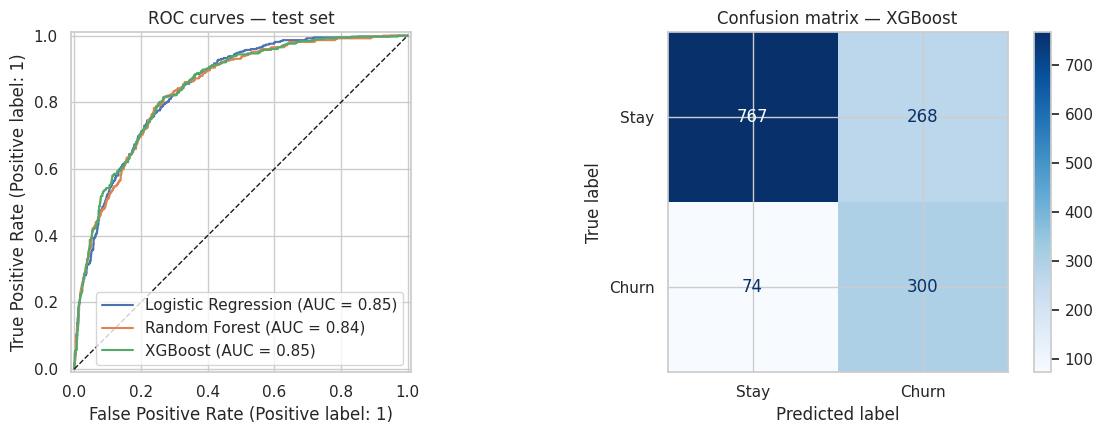

              precision    recall  f1-score   support

        Stay       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [8]:
best = test_results.drop(index="Baseline (majority class)")["F1"].idxmax(); print("Best model (highest F1):", best)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    RocCurveDisplay.from_estimator(fitted[name], X_test, y_test, name=name, ax=axes[0])
axes[0].plot([0,1],[0,1],"k--",lw=1); axes[0].set_title("ROC curves — test set")
ConfusionMatrixDisplay.from_estimator(fitted[best], X_test, y_test, display_labels=["Stay","Churn"], cmap="Blues", ax=axes[1]); axes[1].set_title(f"Confusion matrix — {best}")
plt.tight_layout(); plt.savefig(FIG / "roc_confusion.png", dpi=120); plt.show()
print(classification_report(y_test, fitted[best].predict(X_test), target_names=["Stay","Churn"]))

## 6. Churn drivers

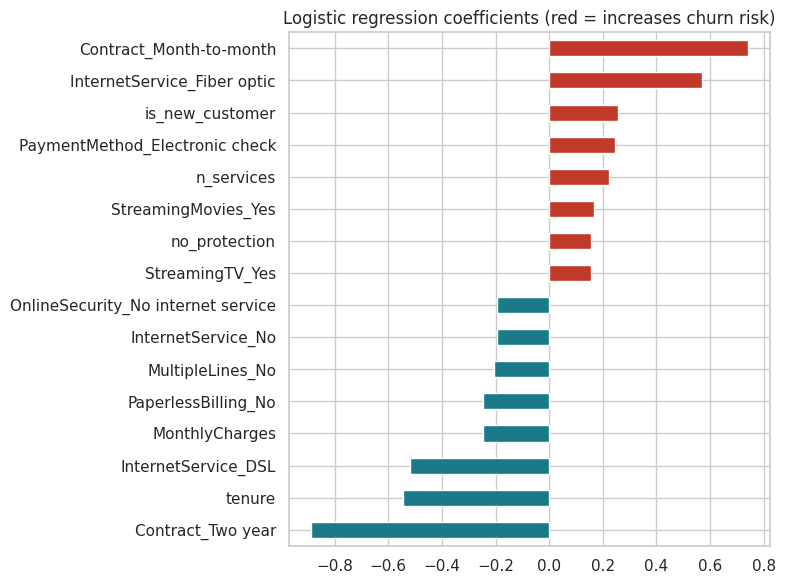

In [9]:
lr = fitted["Logistic Regression"]
names = lr.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(lr.named_steps["model"].coef_[0], index=[n.split("__",1)[1] for n in names]).sort_values()
top = pd.concat([coefs.head(8), coefs.tail(8)])
plt.figure(figsize=(8, 6)); top.plot.barh(color=np.where(top > 0, "#C0392B", "#1A7A8A"))
plt.title("Logistic regression coefficients (red = increases churn risk)"); plt.tight_layout()
plt.savefig(FIG / "churn_drivers.png", dpi=120); plt.show()

In [10]:
# Business view: how many churners do we catch if the retention team contacts the top 20% riskiest customers?
proba = fitted[best].predict_proba(X_test)[:, 1]
k = int(0.2 * len(proba)); top_idx = np.argsort(-proba)[:k]
captured = y_test.iloc[top_idx].sum() / y_test.sum()
print(f"Contacting the top 20% riskiest customers captures {captured:.0%} of all churners (vs 20% with random targeting, lift = {captured/0.2:.1f}x).")

Contacting the top 20% riskiest customers captures 52% of all churners (vs 20% with random targeting, lift = 2.6x).


## 7. Conclusions & recommendations
- The tuned models clearly beat the majority-class baseline (F1 = 0) and reach a ROC-AUC of about **0.85** and a churn recall of about **0.80** on unseen customers; results are consistent between cross-validation and the held-out test set.
- **Main churn drivers:** month-to-month contracts, short tenure, fiber-optic internet, electronic-check payment and the absence of security / tech-support options.
- **Recommendations for the retention team:** offer incentives to move month-to-month customers to 1–2 year contracts, strengthen onboarding during the first 6 months, bundle security/tech-support for fiber customers, and push automatic payment methods.
- **Targeting:** scoring customers and contacting the top 20% riskiest captures roughly half of the churners — a large lift over random campaigns.
- *Next steps:* probability calibration, cost-sensitive threshold choice based on retention offer cost, SHAP explanations per customer.